In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

llc = xr.open_zarr('/orcd/data/abodner/003/LLC4320/LLC4320',consolidated=False)

<>:94: SyntaxWarning: invalid escape sequence '\c'
<>:95: SyntaxWarning: invalid escape sequence '\c'
<>:94: SyntaxWarning: invalid escape sequence '\c'
<>:95: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2361808/3421453827.py:94: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude ($^\circ$)', fontsize=12)
/tmp/ipykernel_2361808/3421453827.py:95: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude ($^\circ$)', fontsize=12)


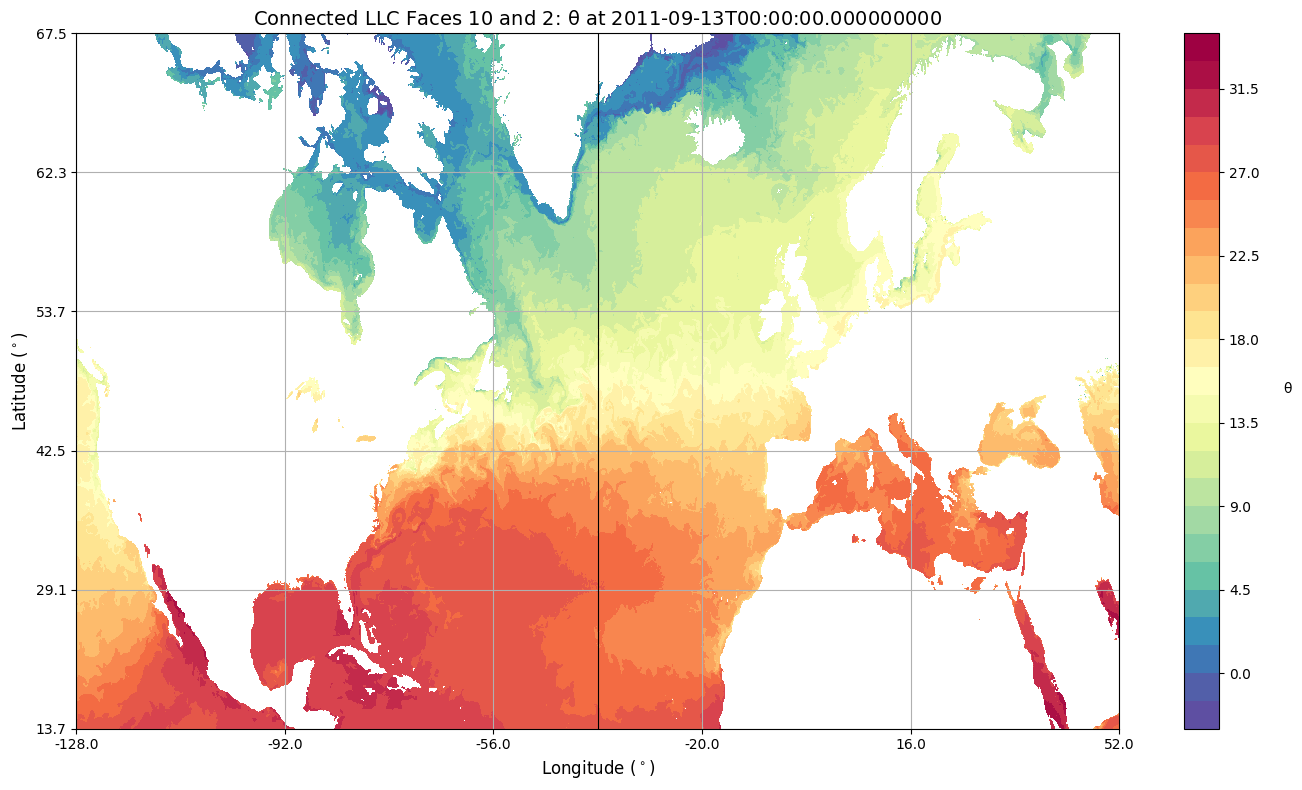

In [7]:



# --------------------------------------------------
# Select LLC face/time/depth
# --------------------------------------------------

llc_sub=llc.isel(k=0,time=0,face=[10,2])

Theta = llc_sub['Theta']

time_str = str(llc_sub.time.values)

# --------------------------------------------------
# Select LLC faces/time/depth
# --------------------------------------------------
llc_sub = llc.isel(k=0, time=0, face=[10, 2])
Theta = llc_sub["Theta"]

time_str = str(llc_sub.time.values)

# Extract faces
theta10 = Theta.sel(face=10).values
theta2  = Theta.sel(face=2).values

lat10 = llc["YC"].sel(face=10).values
lon10 = llc["XC"].sel(face=10).values

lat2 = llc["YC"].sel(face=2).values
lon2 = llc["XC"].sel(face=2).values

# Rotate face 10 90 degrees clockwise
theta10r = np.rot90(theta10, k=1)
lat10r   = np.rot90(lat10,   k=1)
lon10r   = np.rot90(lon10,   k=1)

# Concatenate: face 10 on left, face 2 on right
theta_plot = np.concatenate([theta10r, theta2], axis=1)
lat_plot   = np.concatenate([lat10r,   lat2],   axis=1)
lon_plot   = np.concatenate([lon10r,   lon2],   axis=1)

ny, nx = theta_plot.shape
x = np.arange(nx)
y = np.arange(ny)

# --------------------------------------------------
# Plot in connected index space
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

cf = ax.contourf(
    x,
    y,
    theta_plot,
    cmap="Spectral_r",
    levels=30,
    vmin=np.nanmin(theta_plot),
    vmax=np.nanmax(theta_plot)
)

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label(r'$\theta$', rotation=0, labelpad=20)

# Optional seam line
ax.axvline(theta10r.shape[1] - 0.5, color="k", linewidth=0.8)

# --------------------------------------------------
# Geographic tick labels
# --------------------------------------------------
n_ticks = 6

x_ticks = np.linspace(0, nx - 1, n_ticks)
y_ticks = np.linspace(0, ny - 1, n_ticks)

x_idx = np.round(x_ticks).astype(int)
y_idx = np.round(y_ticks).astype(int)

lat_labels = [
    f"{lat_plot[j, nx // 2]:.1f}"
    for j in y_idx
]

lon_labels = [
    f"{lon_plot[ny // 2, i]:.1f}"
    for i in x_idx
]

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.set_xticklabels(lon_labels)
ax.set_yticklabels(lat_labels)

# --------------------------------------------------
# Labels/title
# --------------------------------------------------
ax.set_xlabel('Longitude ($^\circ$)', fontsize=12)
ax.set_ylabel('Latitude ($^\circ$)', fontsize=12)

ax.set_title(
    f'Connected LLC Faces 10 and 2: $\\theta$ at {time_str}',
    fontsize=14
)

ax.grid(True)

plt.tight_layout()

# plt.savefig(
#     "LLCFaces10_2_connected.png",
#     dpi=400,
#     bbox_inches="tight"
# )

plt.show()

/orcd/home/002/benamran/.conda/envs/my_env/lib/python3.12/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/tmp/ipykernel_3914683/299016537.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


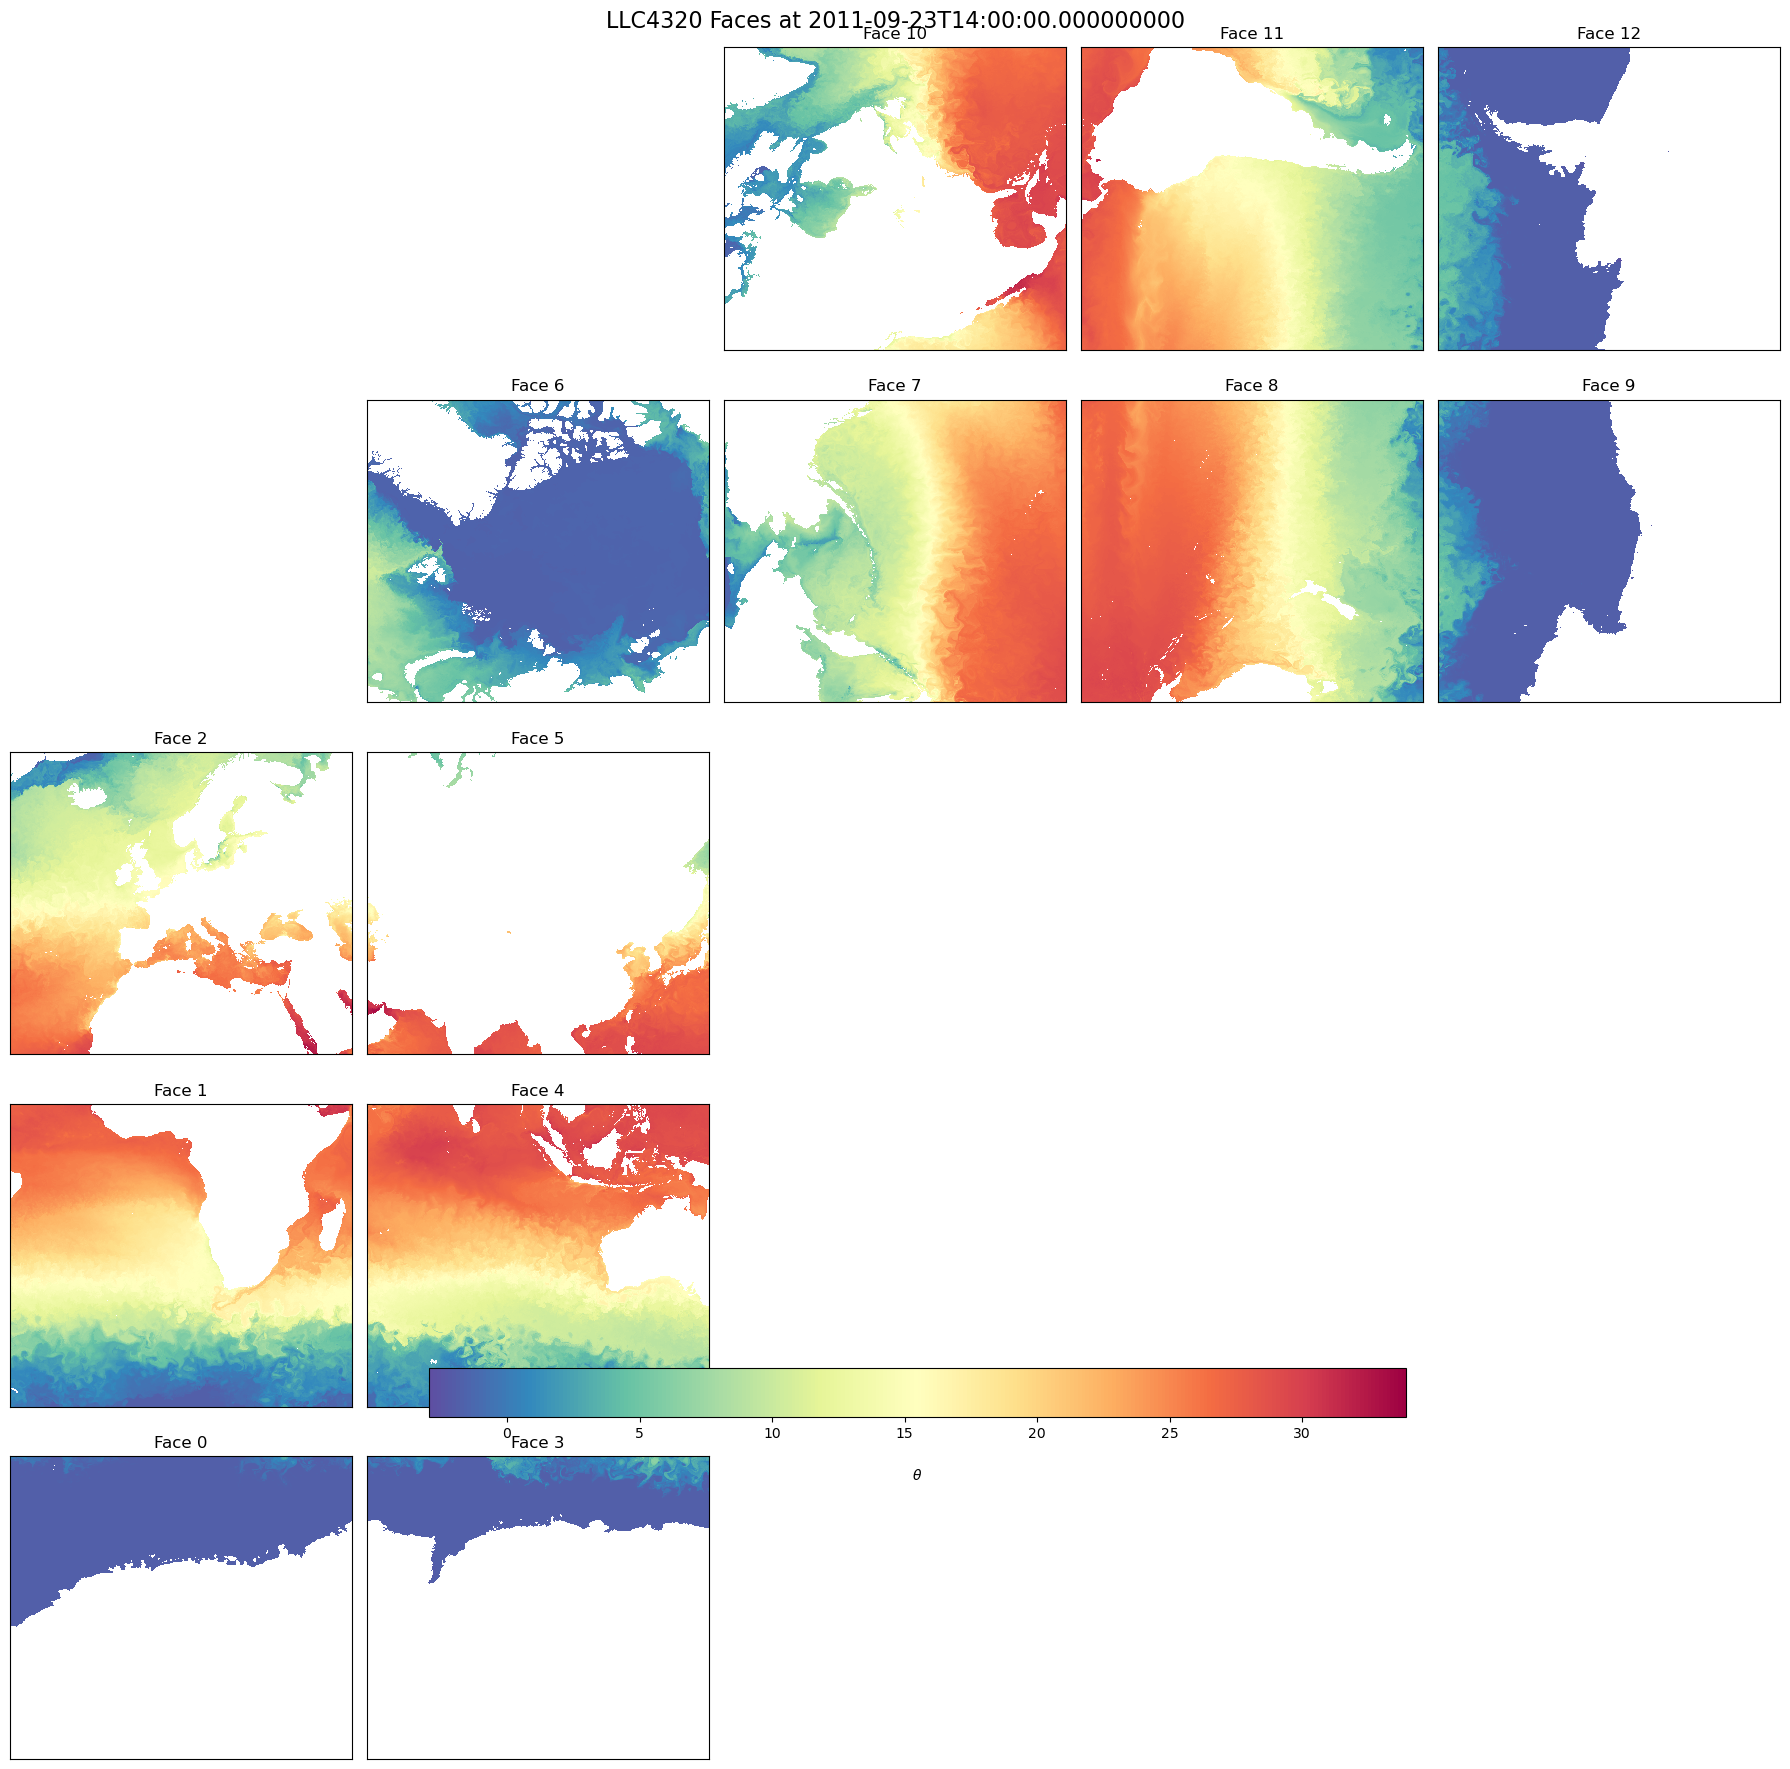

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select one timestep and depth level
llc_sub = llc.isel(k=0, time=254)

# 5x5 LLC-style layout
# Grid positions are (row, col)

layout = {
    0:  (4, 0),
    1:  (3, 0),
    2:  (2, 0),
    3:  (4, 1),
    4:  (3, 1),
    5:  (2, 1),
    6:  (1, 1),
    7:  (1, 2),
    8:  (1, 3),
    9:  (1, 4),
    10: (0, 2),
    11: (0, 3),
    12: (0, 4),
}

fig, axes = plt.subplots(5, 5, figsize=(18, 18))

# Turn everything off initially
for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

# Global color limits
vmin = llc_sub['Theta'].min().values
vmax = llc_sub['Theta'].max().values

# Plot each face
for face in range(13):

    row, col = layout[face]
    ax = axes[row, col]

    ax.axis('on')

    theta = llc_sub['Theta'].sel(face=face)

    pcm = ax.pcolormesh(
        theta,
        cmap='Spectral_r',
        vmin=vmin,
        vmax=vmax,
        shading='auto'
    )

    ax.set_title(f'Face {face}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Shared colorbar
cbar = fig.colorbar(
    pcm,
    ax=axes,
    shrink=0.7,
)

#cbar.set_label(r'$\theta$', rotation=0, labelpad=20)

# Time label
time_str = str(llc_sub.time.values)
fig.suptitle(f'LLC4320 Faces at {time_str}', fontsize=16)

plt.tight_layout()
plt.show()

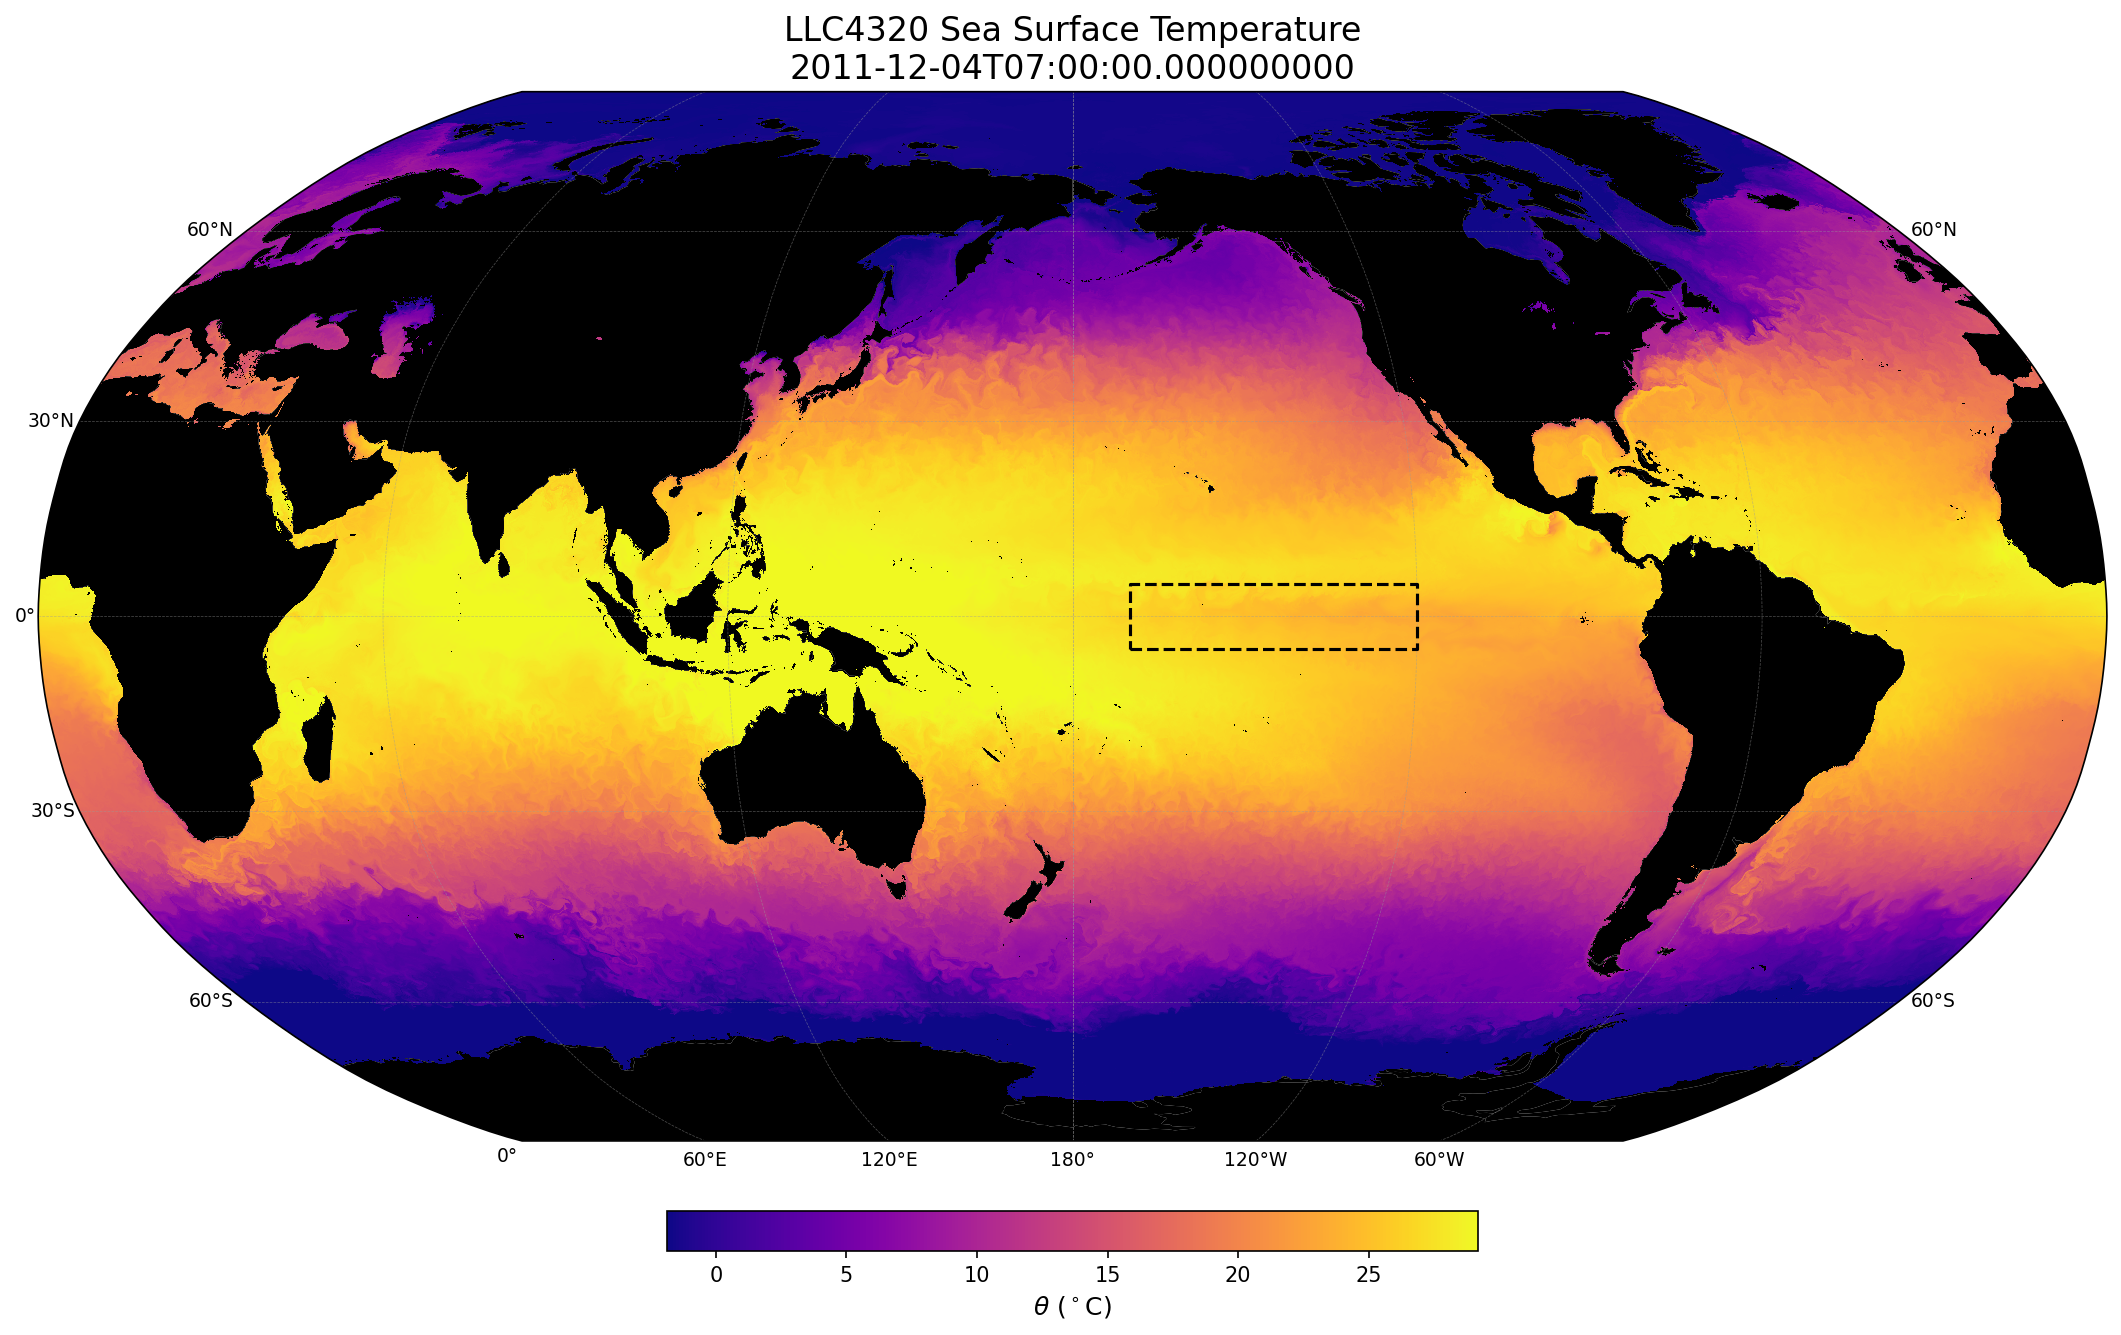

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================
# Toggle variable here — only line to change
# ============================================
plot_var = "Theta"

# ============================================
# Select timestep and surface level
# ============================================
if plot_var == "Eta":
    llc_sub = llc.isel(time=1975)
else:
    llc_sub = llc.isel(time=1975, k=0)

# ============================================
# Variables
# ============================================
data_var = llc_sub[plot_var]
xc = llc["XC"]
yc = llc["YC"]
mask = llc["hFacC"].isel(k=0)

# ============================================
# Data-driven color scaling
# ============================================
raw = data_var.compute().values
valid = np.isfinite(raw) & (raw != 0.0)

if plot_var == "Eta":
    vlim = float(np.nanpercentile(np.abs(raw[valid]), 98))
    norm = colors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)
    cmap = plt.cm.RdBu_r.copy()
    cbar_label = r'SSH (m)'
    title_var = 'Sea Surface Height'
else:
    vmin = float(np.nanpercentile(raw[valid], 2))
    vmax = float(np.nanpercentile(raw[valid], 98))
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.plasma.copy()
    cbar_label = r'$\theta$ ($^\circ$C)'
    title_var = 'Sea Surface Temperature'

# NaNs transparent — lets black background show through
# Must be alpha=0 or cartopy wrapping breaks
cmap.set_bad(alpha=0)

# ============================================
# Projection setup
# ============================================
proj = ccrs.Robinson(central_longitude=180)
data_crs = ccrs.PlateCarree()

# ============================================
# Figure setup
# ============================================
fig = plt.figure(figsize=(16, 9), dpi=150)
ax = plt.axes(projection=proj)
ax.set_global()

# Black background — NaN transparent cells show black underneath
ax.add_feature(cfeature.OCEAN, facecolor='black', edgecolor='none', zorder=0)
ax.add_feature(cfeature.LAND,  facecolor='black', edgecolor='none', zorder=0)

# ============================================
# Plot LLC faces
# ============================================
pcm = None

for face in range(13):

    data_face = data_var.sel(face=face)

    # Apply LLC ocean mask
    data_face = data_face.where(mask.sel(face=face) > 0)

    lon_face = xc.sel(face=face)
    lat_face = yc.sel(face=face)

    pcm = ax.pcolormesh(
        lon_face,
        lat_face,
        data_face,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading='auto',
        rasterized=True,
        zorder=1
    )

# ============================================
# Coastlines
# ============================================
ax.coastlines(linewidth=0.7, color='black', alpha=0, zorder=5)

# ============================================
# Gridlines
# ============================================
gl = ax.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.35,
    color='0.6',
    alpha=0.5,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}

# ============================================
# Niño 3.4 box
# ============================================
ax.plot(
    [-170, -120, -120, -170, -170],
    [-5, -5, 5, 5, -5],
    transform=data_crs,
    color='black',
    linewidth=1.5,
    linestyle="--",
    zorder=6
)

# ============================================
# Colorbar
# ============================================
cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation='horizontal',
    pad=0.06,
    shrink=0.7,
    fraction=0.035
)
cbar.set_label(cbar_label, fontsize=12)

# ============================================
# Title
# ============================================
time_str = str(llc_sub.time.values)
ax.set_title(
    f'LLC4320 {title_var}\n{time_str}',
    fontsize=16
)

plt.tight_layout()
plt.savefig("mapSSTNina1975.png", dpi=450, bbox_inches="tight")
plt.show()

<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2319833/2131241420.py:81: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude ($^\circ$)', fontsize=12)
/tmp/ipykernel_2319833/2131241420.py:82: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude ($^\circ$)', fontsize=12)


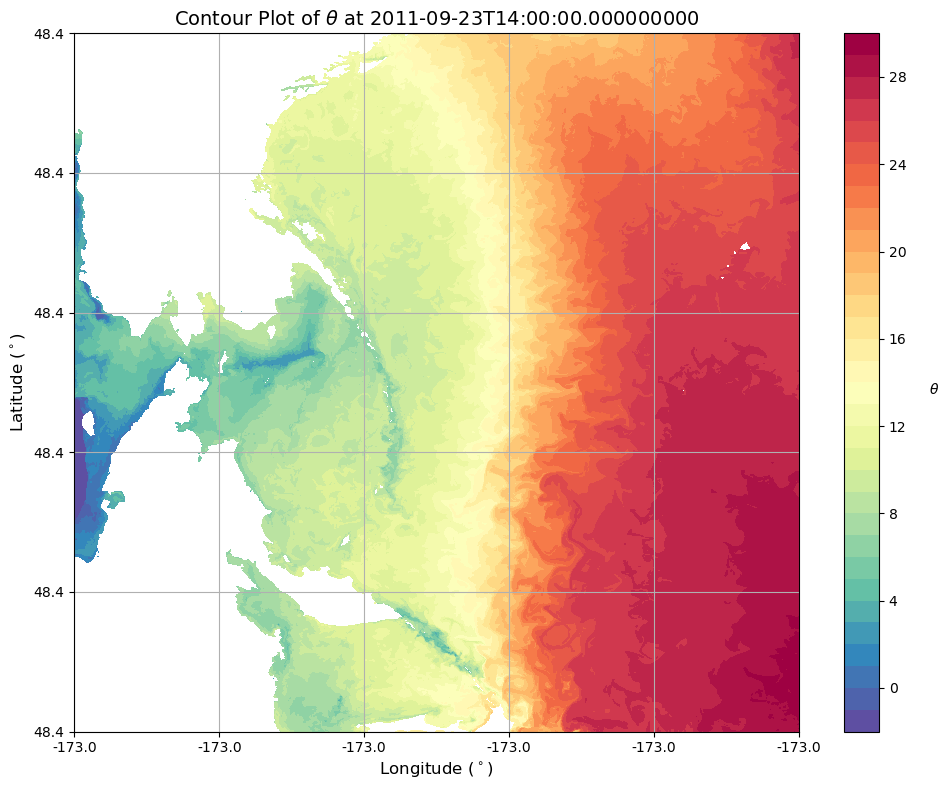